# Clinico-Transcriptomic Discovery of Prognostic Biomarkers and Functional Hallmarks in TCGA Breast Cancer Using Python
---
   ## Notebook 3: DIfferential Expression Analysis


### 1. Biological Motivation

While exploratory analysis in Notebook 2 established that global transcriptomic variation does not naturally separate patients by survival status, it remains unclear whether specific genes or pathways are systematically associated with clinical outcome.

Cancer biology is often driven not by global expression shifts, but by subtle, coordinated changes in a subset of genes, including:
* Oncogenes that become aberrantly activated
* Tumor suppressor genes that are transcriptionally silenced
* Immune signaling genes reflecting microenvironment disruption
* Tissue-specific genes reflecting loss of cellular identity

This notebook therefore transitions from unsupervised structure learning (PCA) to supervised statistical inference, aiming to answer:
> Which genes are significantly differentially expressed between patients who survived vs. those who died?

> Is the expression change pattern dominated by upregulation or downregulation in high-risk patients?

> Which genes emerge as the most statistically robust survival-associated signals?

> Do these genes reflect known cancer biology or novel candidate biomarkers?

> What biological processes are most disrupted in aggressive breast carcinoma?

### 2. Import Required Libraries

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

### 3. Load Processed Expression and Clinical Data

We use the pristine, QC-filtered dataset generated in Notebook 1, which contains:
* 19,962 protein-coding genes
* 1,019 matched patient samples
* Strict alignment between expression and survival metadata

In [2]:
sns.set_theme(style="whitegrid")

counts_raw = pd.read_csv("../data/processed/brca_counts_cleaned.csv", index_col=0)
clinical = pd.read_csv("../data/processed/brca_clinical_cleaned.csv", index_col=0)

X_counts = counts_raw.T

print(f"Counts shape for DESeq2 (Samples x Genes): {X_counts.shape}")
print(f"Clinical metadata shape: {clinical.shape}")

counts_raw

Counts shape for DESeq2 (Samples x Genes): (1019, 19962)
Clinical metadata shape: (1019, 8)


,TCGA-3C-AAAU,TCGA-3C-AALI,TCGA-3C-AALJ,TCGA-3C-AALK,TCGA-4H-AAAK,TCGA-5L-AAT1,TCGA-5T-A9QA,TCGA-A1-A0SB,TCGA-A1-A0SD,TCGA-A1-A0SE,...,TCGA-S3-AA14,TCGA-S3-AA15,TCGA-UL-AAZ6,TCGA-UU-A93S,TCGA-V7-A7HQ,TCGA-W8-A86G,TCGA-WT-AB44,TCGA-XX-A899,TCGA-XX-A89A,TCGA-Z7-A8R6
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003.15,651,418,1303,2969,2572,929,1569,4148,2477,5089,...,2036,1159,938,350,2293,4914,716,2077,1790,2163
ENSG00000000005.6,2,2,52,4,15,3,1,604,50,24,...,7,40,1,36,5,19,24,20,1021,6
ENSG00000000419.13,1872,1818,1281,1386,1439,933,2210,1194,2775,1563,...,1010,1220,1158,1308,703,1507,617,1588,1216,2229
ENSG00000000457.14,951,2437,380,1315,1008,802,1158,996,1430,1769,...,783,700,1036,997,317,1404,769,1461,982,1323
ENSG00000000460.17,339,490,239,460,366,143,463,337,375,1308,...,339,839,402,518,49,348,122,397,414,1246
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000288661.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000288669.1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
ENSG00000288671.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### 4. Pre-Analysis Quality Control for Differential Expression: Low-Count Gene Filtering

Genes with extremely low expression across samples introduce noise and reduce statistical power.

We retain genes expressed at meaningful levels in at least 10% of patients.

In [3]:
min_samples = int(0.10 * X_counts.shape[0])
keep_genes = (X_counts >= 10).sum(axis=0) >= min_samples
X_counts_filtered = X_counts.loc[:, keep_genes]

X_counts_filtered = X_counts_filtered.astype(int)

print(f"Filtered matrix ready for DESeq2: {X_counts_filtered.shape}")

Filtered matrix ready for DESeq2: (1019, 16790)


### 5. Statistical Modeling Framework (DESeq2)

We apply a negative binomial generalized linear model (GLM) using DESeq2 to test:

* H₀: No difference in gene expression between Alive vs Dead patients
* H₁: Gene expression differs significantly by survival status

#### 5.1. Design Matrix Preparation

In [4]:
clinical["vital_status"] = clinical["vital_status"].astype(str)

clinical["vital_status"] = pd.Categorical(clinical["vital_status"], categories=["Alive", "Dead"])

print("Design factor column successfully formatted as a categorical type.")
print(f"Categories detected: {clinical['vital_status'].cat.categories.tolist()}")
print(f"Baseline Reference Group (Index 0): {clinical['vital_status'].cat.categories[0]}")

Design factor column successfully formatted as a categorical type.
Categories detected: ['Alive', 'Dead']
Baseline Reference Group (Index 0): Alive


#### 5.2. Fitting the Differential Expression Model

In [5]:
print("--- Initializing DESeqDataSet ---")
dds = DeseqDataSet(
    counts=X_counts_filtered,
    metadata=clinical,
    design_factors="vital_status",
    refit_cooks=True,
    n_cpus=4 
)

print("\n--- Running DESeq2 Dispersion and Size Factor Fitting ---")
dds.deseq2()

--- Initializing DESeqDataSet ---


C:\Users\Nonye\AppData\Local\Temp\ipykernel_19044\3635426139.py:2: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...



--- Running DESeq2 Dispersion and Size Factor Fitting ---
Using None as control genes, passed at DeseqDataSet initialization


... done in 1.14 seconds.

Fitting dispersions...
... done in 38.43 seconds.

Fitting dispersion trend curve...
... done in 1.53 seconds.

Fitting MAP dispersions...
... done in 32.26 seconds.

Fitting LFCs...
... done in 14.62 seconds.

Calculating cook's distance...
... done in 1.50 seconds.

Replacing 2263 outlier genes.

Fitting dispersions...
... done in 4.40 seconds.

Fitting MAP dispersions...
... done in 3.90 seconds.

Fitting LFCs...
... done in 3.08 seconds.



#### 5.3. Differential Expression Testing

In [6]:
print("--- Extracting Wald Test Statistical Summaries ---")

stat_res = DeseqStats(
    dds, 
    contrast=["vital_status", "Dead", "Alive"], 
    n_cpus=4
)

stat_res.summary()

results_df = stat_res.results_df

--- Extracting Wald Test Statistical Summaries ---


Running Wald tests...


Log2 fold change & Wald test p-value: vital_status Dead vs Alive
                       baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                         
ENSG00000000003.15  3025.289415        0.023288  0.086206  0.270147  0.787047   
ENSG00000000005.6     36.989057       -0.328507  0.192338 -1.707963  0.087643   
ENSG00000000419.13  2407.537108       -0.008162  0.051534 -0.158374  0.874162   
ENSG00000000457.14  1596.907265        0.016203  0.050978  0.317851  0.750598   
ENSG00000000460.17   735.340136        0.031622  0.068358  0.462589  0.643659   
...                         ...             ...       ...       ...       ...   
ENSG00000288558.2    304.993292        0.029315  0.058956  0.497242  0.619018   
ENSG00000288611.1      7.698739       -0.780397  0.226503 -3.445411  0.000570   
ENSG00000288658.1     23.896391       -0.160810  0.194777 -0.825610  0.409025   
ENSG00000288674.1      7.865320       -0.080

... done in 3.27 seconds.



### 6. Global Differential Expression Landscape

We define significance thresholds:

- adjusted p-value (FDR) < 0.05
- |log2FoldChange| > 1

In [7]:
upregulated = (
    (results_df["padj"] < 0.05)
    & (results_df["log2FoldChange"] > 1)
).sum()

downregulated = (
    (results_df["padj"] < 0.05)
    & (results_df["log2FoldChange"] < -1)
).sum()

print(f"Number of Upregulated genes: {upregulated}\nNumber of Downregulated genes: {downregulated}")

Number of Upregulated genes: 8
Number of Downregulated genes: 168


### Interpretation:

Downregulated genes vastly outnumber upregulated genes (168 vs 8)

This skewed distribution suggests that poor survival in breast cancer is not primarily driven by oncogene overactivation, but rather by:

- Loss of Cellular Identity: Aggressive tumors exhibit, dedifferentiation, loss of epithelial structure and shutdown of tissue-specific gene programs. Downregulated genes likely include: tumor suppressors, adhesion molecules and epithelial identity markers
- Tumor Microenvironment Collapse: Downregulated genes may reflect reduced immune signaling, immune evasion mechanisms and suppression of cytokine activity

Unlike highly proliferative cancers (e.g. glioblastoma), TCGA-BRCA survival disparity appears to be driven by transcriptional silencing and functional collapse rather than hyperactivation alone

### 7. Annotation of Differentially Expressed Genes

#### 7.1. Retrieve gene name from manifest file

In [8]:
manifest = pd.read_csv("../data/manifest/gdc_manifest.csv")

output_dir = "../data/raw/tcga_counts/" 
file_path = os.path.join(output_dir, manifest.iloc[0,0], manifest.iloc[0,1])
df = pd.read_csv(file_path, sep="\t", comment="#", skiprows=[1, 2, 3, 4])
df.columns = [
        "gene_id", "gene_name", "gene_type", 
        "unstranded", "stranded_first", "stranded_second", 
        "tpm_unstranded", "fpkm_unstranded", "fpkm_uq_unstranded"
    ]

#### 7.2. Map gene name to results_df

In [9]:
gene_name_lookup = df[["gene_id", "gene_type", "gene_name"]].copy()

results_annotated = results_df.reset_index().merge(
    gene_name_lookup, 
    on="gene_id", 
    how="left"
).set_index("gene_id")

columns_ordered = ["gene_name", "gene_type", "log2FoldChange", "lfcSE", "stat", "pvalue", "padj"]
results_annotated = results_annotated[columns_ordered]

### 8. Key Differentially Expressed Genes in High-Risk Patients

In [10]:
top_upregulated = results_annotated[
    (results_annotated["padj"] < 0.05) & (results_annotated["log2FoldChange"] > 1)
].sort_values(by="padj")

print("--- TOP 8 UPREGULATED GENES (HIGH-RISK BIOMARKERS) ---")
print(top_upregulated[["gene_name", "log2FoldChange", "pvalue", "padj"]])

--- TOP 8 UPREGULATED GENES (HIGH-RISK BIOMARKERS) ---
                   gene_name  log2FoldChange        pvalue          padj
gene_id                                                                 
ENSG00000119283.15    TRIM67        1.276851  7.388458e-22  6.202611e-18
ENSG00000089250.19      NOS1        1.317790  1.341763e-14  1.732939e-11
ENSG00000170835.16       CEL        1.058846  4.554482e-11  2.249110e-08
ENSG00000182759.4       MAFA        1.151444  3.132681e-09  1.073423e-06
ENSG00000188505.5     NCCRP1        1.198463  1.257801e-07  2.335718e-05
ENSG00000130720.13    FIBCD1        1.012873  6.961153e-07  9.202973e-05
ENSG00000163631.17       ALB        1.116474  1.067227e-06  1.279910e-04
ENSG00000171209.3       CSN3        2.272288  2.878344e-05  1.796558e-03


#### Interpretation:

The most significantly upregulated genes include:

**TRIM67**
- E3 ubiquitin ligase
- potential regulator of protein degradation pathways
- implicated in oncogenic signaling rewiring (NF-κB, Wnt/β-catenin)
  
**NOS1**
- nitric oxide signaling enzyme
- promotes angiogenesis and oxidative stress tolerance
- supports tumor survival under hypoxia
  
**CSN3**
- lactation-associated protein (casein family)
- reflects lineage reactivation and differentiation collapse
- associated with metastatic adaptability
  
**ALB / CEL**
- liver/pancreatic metabolic genes
- evidence of metabolic reprogramming and lineage infidelity

### 9. Volcano Plot: Global Differential Expression Structure

In [11]:
results_annotated["Significance"] = "Not Significant"

results_annotated.loc[
    (results_annotated["log2FoldChange"] > 1) & (results_annotated["padj"] < 0.05), 
    "Significance"
] = "Upregulated (Dead)"

results_annotated.loc[
    (results_annotated["log2FoldChange"] < -1) & (results_annotated["padj"] < 0.05), 
    "Significance"
] = "Downregulated (Dead)"

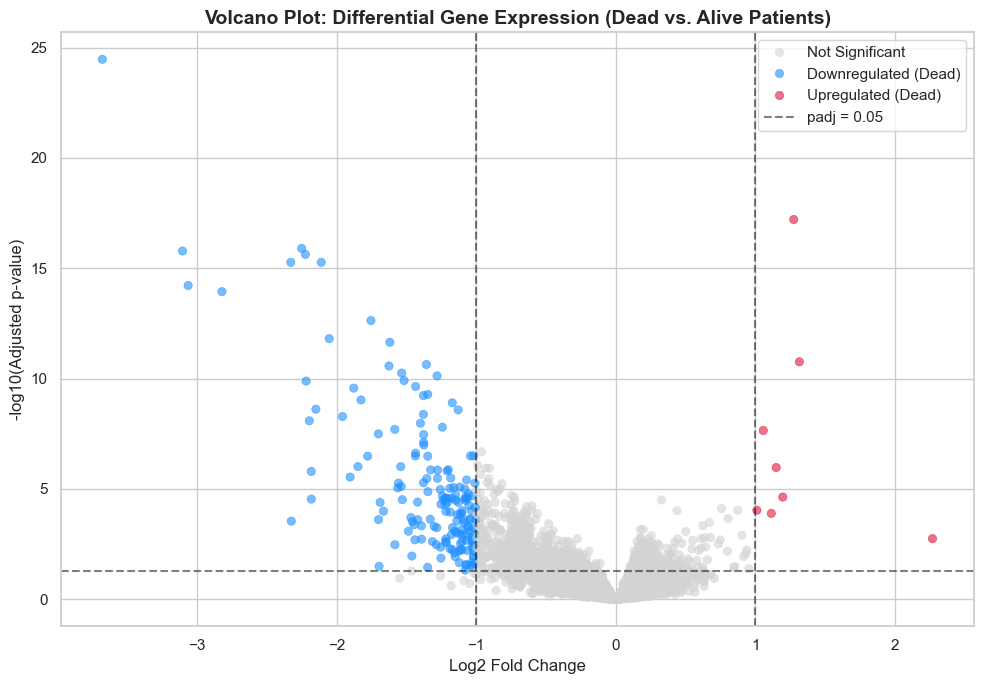

In [12]:
plot_df = results_annotated.dropna(subset=["padj"]).copy()

plot_df["-log10(padj)"] = -np.log10(plot_df["padj"])

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x="log2FoldChange", 
    y="-log10(padj)", 
    hue="Significance", 
    palette={"Not Significant": "lightgrey", "Upregulated (Dead)": "crimson", "Downregulated (Dead)": "dodgerblue"},
    alpha=0.6,
    edgecolor=None,
    data=plot_df
)

plt.axhline(-np.log10(0.05), color="black", linestyle="--", alpha=0.5, label="padj = 0.05")
plt.axvline(1, color="black", linestyle="--", alpha=0.5)
plt.axvline(-1, color="black", linestyle="--", alpha=0.5)

plt.title("Volcano Plot: Differential Gene Expression (Dead vs. Alive Patients)", fontsize=14, fontweight="bold")
plt.xlabel("Log2 Fold Change", fontsize=12)
plt.ylabel("-log10(Adjusted p-value)", fontsize=12)
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig(f"../results/figures/dgea_volcano.png", dpi=300, bbox_inches="tight",)
plt.show()

### 10. Ranking of Survival-Associated Biomarkers

In [13]:
results_annotated["Significance"] = pd.Categorical(
    results_annotated["Significance"], 
    categories=["Upregulated (Dead)", "Downregulated (Dead)", "Not Significant"],
    ordered=True
)

ranked_result = results_annotated.sort_values(by=["Significance", "padj"], ascending=[True, True])

final_column_layout = [
    "gene_name", "gene_type", "Significance", 
    "log2FoldChange", "pvalue", "padj", "stat", "lfcSE"
]
ranked_result = ranked_result[final_column_layout]

In [14]:
ranked_result.to_csv("../results/tables/brca_dgea_master_results.csv")
print("DESeq2 results exported to results directory successfully!")

DESeq2 results exported to results directory successfully!


### Notebook Summary

This notebook evaluated the transcriptomic differences between high-risk and low-risk breast cancer patient groups, uncovering the statistical and biological mechanisms driving patient survival.

**Most Important Insight**
> Survival-associated transcriptional signals are not dominated by classical breast cancer oncogenes (e.g., HER2, MYC), but by system-wide regulatory collapse and lineage reprogramming

This analysis demonstrates that:

- Differential expression between survival groups is statistically robust but biologically distributed
- Downregulation dominates the survival signature, indicating loss of cellular identity as a key feature of aggressive disease
- A small set of highly significant genes emerges as candidate prognostic biomarkers
- Survival prediction will require multi-gene systems modeling rather than single-gene interpretation